## Imports

In [15]:
## Imports
import os
import sys
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset

# Se placer à la racine du projet
project_root = Path.cwd()

if not (project_root / "api").exists():
    project_root = project_root.parent

os.chdir(project_root)
sys.path.insert(0, str(project_root))

load_dotenv()

from api.main import apply_feature_engineering



## 1. Chargement des données de référence

In [16]:
chemin_reference = "data/reference_data.csv"
reference_data = pd.read_csv(chemin_reference)


## 2. Chargement des données de production (logs de l'API)

In [17]:
DATABASE_URL = os.getenv("DATABASE_URL")

if DATABASE_URL and DATABASE_URL.startswith("postgres://"):
    DATABASE_URL = DATABASE_URL.replace("postgres://", "postgresql://", 1)

if not DATABASE_URL:
    raise ValueError("La variable DATABASE_URL n'est pas configurée dans le fichier .env")

engine = create_engine(DATABASE_URL)
## 2.1 Monitoring opérationnel des logs API

query_monitoring = """
SELECT 
    status,
    execution_time,
    timestamp
FROM prediction_logs
"""

df_monitoring = pd.read_sql(query_monitoring, engine)

print("Nombre total d'appels API :", len(df_monitoring))

if not df_monitoring.empty:
    nb_success = (df_monitoring["status"] == "success").sum()
    nb_errors = (df_monitoring["status"] != "success").sum()
    taux_erreur = nb_errors / len(df_monitoring) * 100

    latence_moyenne = df_monitoring["execution_time"].mean()
    latence_mediane = df_monitoring["execution_time"].median()
    latence_max = df_monitoring["execution_time"].max()

    print("Nombre de succès :", nb_success)
    print("Nombre d'erreurs :", nb_errors)
    print(f"Taux d'erreur : {taux_erreur:.2f} %")
    print(f"Latence moyenne : {latence_moyenne:.4f} s")
    print(f"Latence médiane : {latence_mediane:.4f} s")
    print(f"Latence maximale : {latence_max:.4f} s")
else:
    print("Aucun log disponible pour le monitoring opérationnel.")
query = "SELECT input_data FROM prediction_logs WHERE status = 'success'"
df_logs = pd.read_sql(query, engine)

if df_logs.empty:
    print("La base de données ne contient aucun log d'inférence en succès.")
    production_data = pd.DataFrame(columns=reference_data.columns)
else:
    production_data = pd.json_normalize(df_logs['input_data'])
    print(f"Données de production chargées depuis Neon : {production_data.shape[0]} lignes.")

Nombre total d'appels API : 4
Nombre de succès : 4
Nombre d'erreurs : 0
Taux d'erreur : 0.00 %
Latence moyenne : 0.0207 s
Latence médiane : 0.0207 s
Latence maximale : 0.0208 s
Données de production chargées depuis Neon : 4 lignes.


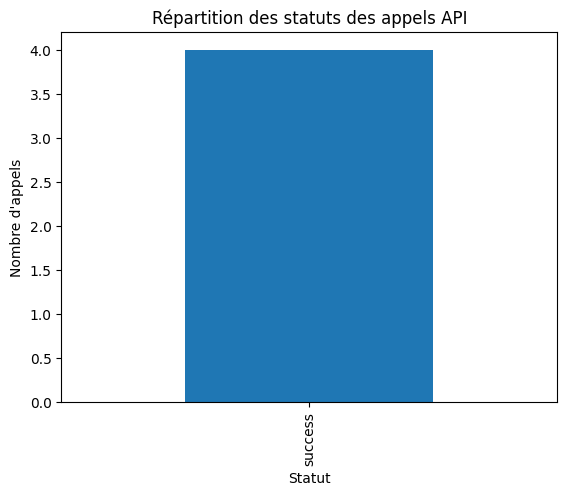

In [18]:
## 2.2 Graphique - Répartition des statuts

if not df_monitoring.empty:
    df_monitoring["status"].value_counts().plot(kind="bar")
    plt.title("Répartition des statuts des appels API")
    plt.xlabel("Statut")
    plt.ylabel("Nombre d'appels")
    plt.show()

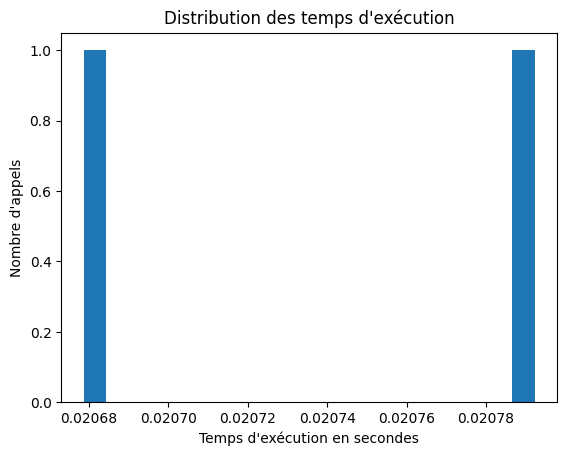

In [19]:
## 2.3 Graphique - Distribution des temps d'exécution

if not df_monitoring.empty:
    df_monitoring["execution_time"].dropna().plot(kind="hist", bins=20)
    plt.title("Distribution des temps d'exécution")
    plt.xlabel("Temps d'exécution en secondes")
    plt.ylabel("Nombre d'appels")
    plt.show()

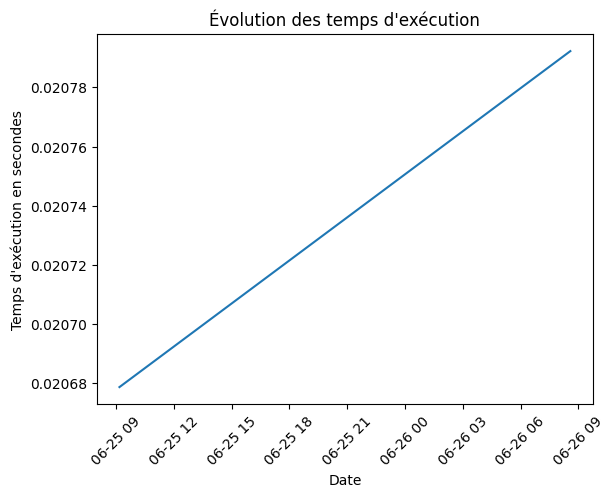

In [20]:
## 2.4 Graphique - Évolution de la latence dans le temps

if not df_monitoring.empty:
    df_monitoring["timestamp"] = pd.to_datetime(df_monitoring["timestamp"])
    df_monitoring_sorted = df_monitoring.sort_values("timestamp")

    plt.plot(df_monitoring_sorted["timestamp"], df_monitoring_sorted["execution_time"])
    plt.title("Évolution des temps d'exécution")
    plt.xlabel("Date")
    plt.ylabel("Temps d'exécution en secondes")
    plt.xticks(rotation=45)
    plt.show()


## 3. Application du même feature engineering que l'API


In [21]:
with open("api/expected_features.json", "r") as f:
    expected_features = json.load(f)

reference_engineered = apply_feature_engineering(reference_data)
production_engineered = apply_feature_engineering(production_data)

reference_data_aligned = reference_engineered.reindex(
    columns=expected_features,
    fill_value=0
)

production_data_aligned = production_engineered.reindex(
    columns=expected_features,
    fill_value=0
)

## 4. Initialisation du rapport avec les métriques de Data Drift

In [22]:
drift_report = Report(metrics=[DataDriftPreset()])



## 5. Calcul des statistiques comparatives (Référence vs Production)


In [23]:
## 5. Calcul des statistiques comparatives (Référence vs Production)

dataset_drift_metric = None

if not production_data_aligned.empty:
    # Lancement des calculs
    drift_report.run(
        reference_data=reference_data_aligned,
        current_data=production_data_aligned
    )

    ## 5.1 Synthèse des métriques de Data Drift

    drift_results = drift_report.as_dict()

    for metric in drift_results["metrics"]:
        if "DatasetDriftMetric" in metric["metric"]:
            dataset_drift_metric = metric["result"]
            break

    if dataset_drift_metric:
        dataset_drift_detected = dataset_drift_metric.get("dataset_drift")
        nb_columns = dataset_drift_metric.get("number_of_columns")
        nb_drifted_columns = dataset_drift_metric.get("number_of_drifted_columns")
        drift_share = dataset_drift_metric.get("share_of_drifted_columns")

        print("Dataset Drift détecté :", dataset_drift_detected)
        print("Nombre total de colonnes analysées :", nb_columns)
        print("Nombre de colonnes en drift :", nb_drifted_columns)
        print(f"Part des colonnes en drift : {drift_share * 100:.2f} %")
    else:
        print("Impossible d'extraire automatiquement les métriques de Data Drift.")

    # Affichage du rapport Evidently directement dans le notebook
    drift_report.show(mode="inline")

else:
    print("Calcul impossible : le jeu de données de production est vide.")

c:\Users\ethan\Documents\OpenClassrooms\MLops_2\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\ethan\Documents\OpenClassrooms\MLops_2\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7192: RuntimeWarning: divide by zero encountered in divide
  terms = (f_obs - f_exp)**2 / f_exp
c:\Users\ethan\Documents\OpenClassrooms\MLops_2\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7192: RuntimeWarning: divide by zero encountered in divide
  terms = (f_obs - f_exp)**2 / f_exp
c:\Users\ethan\Documents\OpenClassrooms\MLops_2\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7192: RuntimeWarning: divide by zero encountered in divide
  terms = (f_obs - f_exp)**2 / f_exp
c:\Users\ethan\Documents\OpenClassrooms\MLops_2\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7192: RuntimeWarning: divide by zero encountered in divide
  terms = (f_obs - f_exp)**2 / f_exp
c:\Users\ethan\Documents\OpenClassrooms\ML

Dataset Drift détecté : False
Nombre total de colonnes analysées : 471
Nombre de colonnes en drift : 134
Part des colonnes en drift : 28.45 %


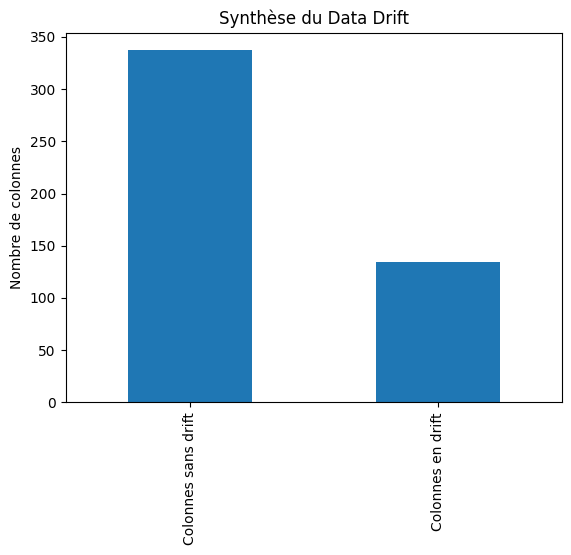

In [24]:
## 5.2 Graphique - Colonnes avec / sans drift

if dataset_drift_metric:
    nb_non_drifted_columns = nb_columns - nb_drifted_columns

    df_drift_summary = pd.DataFrame({
        "Catégorie": ["Colonnes sans drift", "Colonnes en drift"],
        "Nombre de colonnes": [nb_non_drifted_columns, nb_drifted_columns]
    })

    df_drift_summary.plot(
        x="Catégorie",
        y="Nombre de colonnes",
        kind="bar",
        legend=False
    )

    plt.title("Synthèse du Data Drift")
    plt.xlabel("")
    plt.ylabel("Nombre de colonnes")
    plt.show()
else:
    print("Graphique de synthèse du drift non généré.")

In [25]:
## 5.3 Extraction détaillée des features en drift

data_drift_table = None

for metric in drift_results["metrics"]:
    if "DataDriftTable" in metric["metric"]:
        data_drift_table = metric["result"]
        break

if data_drift_table:
    drift_by_columns = data_drift_table.get("drift_by_columns", {})

    rows = []

    for feature_name, values in drift_by_columns.items():
        rows.append({
            "feature": feature_name,
            "drift_detected": values.get("drift_detected"),
            "drift_score": values.get("drift_score"),
            "stattest_name": values.get("stattest_name")
        })

    df_features_drift = pd.DataFrame(rows)
    df_features_drift["drift_score"] = pd.to_numeric(
        df_features_drift["drift_score"],
        errors="coerce"
    )

    display(
        df_features_drift
        .sort_values(["drift_detected", "drift_score"], ascending=[False, False])
        .head(15)
    )

else:
    df_features_drift = pd.DataFrame()
    print("Impossible d'extraire le détail des features en drift.")

,feature,drift_detected,drift_score,stattest_name
290,PREV_CHANNEL_TYPE_Credit and cash offices,True,0.049787,chi-square p_value
398,PREV_NAME_YIELD_GROUP_middle,True,0.049787,chi-square p_value
69,COMMONAREA_MEDI,True,0.025347,Z-test p_value
111,ELEVATORS_AVG,True,0.025347,Z-test p_value
145,FLOORSMIN_AVG,True,0.025347,Z-test p_value
161,LANDAREA_MEDI,True,0.025347,Z-test p_value
187,NONLIVINGAPARTMENTS_AVG,True,0.025347,Z-test p_value
188,NONLIVINGAREA_AVG,True,0.025347,Z-test p_value
449,YEARS_BUILD_MEDI,True,0.025347,Z-test p_value
131,FLAG_DOCUMENT_3,True,0.016395,Z-test p_value


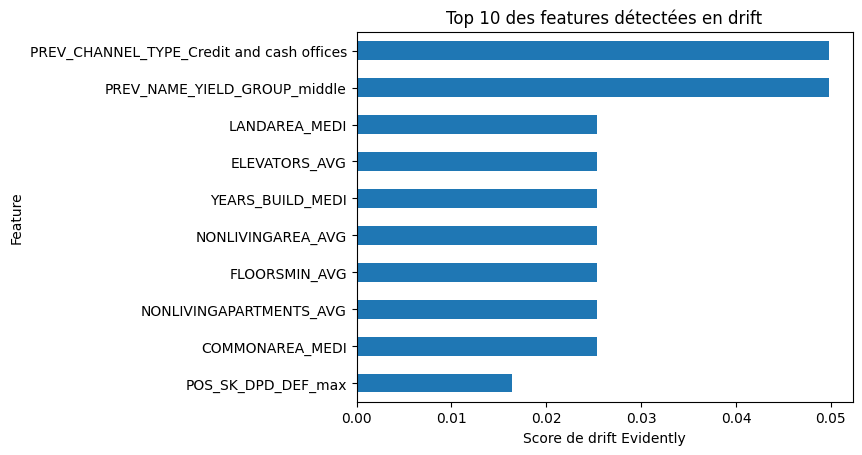

In [26]:
## 5.4 Graphique - Top features détectées en drift

if not df_features_drift.empty:
    df_top_drift = df_features_drift[
        df_features_drift["drift_detected"] == True
    ].copy()

    if df_top_drift.empty:
        print("Aucune feature détectée en drift.")
    else:
        df_top_drift = df_top_drift.sort_values(
            "drift_score",
            ascending=False
        ).head(10)

        df_top_drift.sort_values("drift_score").plot(
            x="feature",
            y="drift_score",
            kind="barh",
            legend=False
        )

        plt.title("Top 10 des features détectées en drift")
        plt.xlabel("Score de drift Evidently")
        plt.ylabel("Feature")
        plt.show()
else:
    print("Graphique des features en drift non généré.")

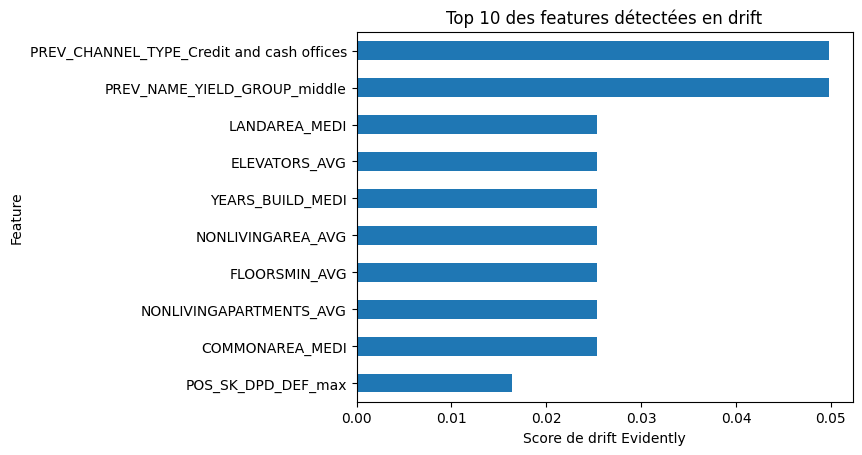

In [27]:
## 5.4 Graphique - Top features détectées en drift

if not df_features_drift.empty:
    df_top_drift = df_features_drift[
        df_features_drift["drift_detected"] == True
    ].copy()

    if df_top_drift.empty:
        print("Aucune feature détectée en drift.")
    else:
        df_top_drift = df_top_drift.sort_values(
            "drift_score",
            ascending=False
        ).head(10)

        df_top_drift.sort_values("drift_score").plot(
            x="feature",
            y="drift_score",
            kind="barh",
            legend=False
        )

        plt.title("Top 10 des features détectées en drift")
        plt.xlabel("Score de drift Evidently")
        plt.ylabel("Feature")
        plt.show()
else:
    print("Graphique des features en drift non généré.")


## 6. Sauvegarde du rapport interactif


In [28]:
if not production_data_aligned.empty:
    os.makedirs("reports", exist_ok=True)

    chemin_rapport = "reports/data_drift_report.html"
    drift_report.save_html(chemin_rapport)

    print(f"Rapport généré avec succès et sauvegardé sous : {chemin_rapport}")
else:
    print("Aucun rapport à sauvegarder.")

Rapport généré avec succès et sauvegardé sous : reports/data_drift_report.html


In [29]:
## 7. Synthèse des optimisations de performance

df_perf = pd.DataFrame({
    "Version": ["Modèle .pkl", "Modèle ONNX"],
    "Latence moyenne (s)": [1.5151, 0.0260],
    "CPU (%)": [4.10, 4.30],
    "RAM (MB)": [85.78, 86.04]
})

df_perf

,Version,Latence moyenne (s),CPU (%),RAM (MB)
0,Modèle .pkl,1.5151,4.1,85.78
1,Modèle ONNX,0.0260,4.3,86.04


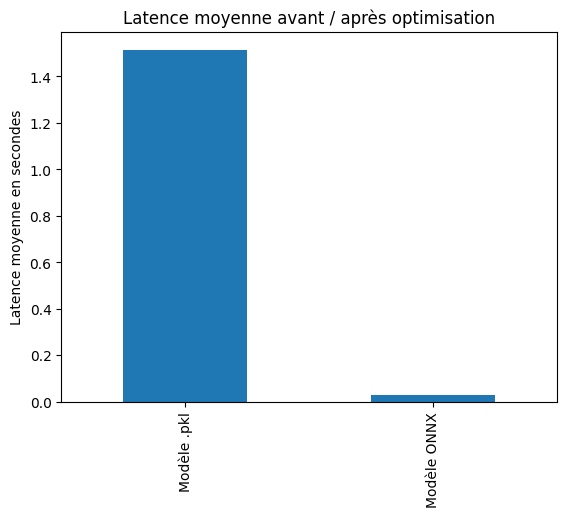

In [30]:
## 7.1 Graphique - Latence avant / après optimisation

df_perf.plot(
    x="Version",
    y="Latence moyenne (s)",
    kind="bar",
    legend=False
)

plt.title("Latence moyenne avant / après optimisation")
plt.xlabel("")
plt.ylabel("Latence moyenne en secondes")
plt.show()

In [31]:
gain_reduction = (1 - 0.0260 / 1.5151) * 100
gain_factor = 1.5151 / 0.0260

print(f"Réduction de la latence : {gain_reduction:.1f} %")
print(f"Gain de performance : environ {gain_factor:.1f} fois plus rapide")

Réduction de la latence : 98.3 %
Gain de performance : environ 58.3 fois plus rapide


## Conclusion

Ce notebook présente deux niveaux de monitoring.

Le premier niveau correspond au monitoring opérationnel de l'API. Les logs stockés en base PostgreSQL/Neon permettent de suivre le nombre d'appels, le statut des requêtes, le taux d'erreur et les temps d'exécution. Ces métriques donnent une première vision de la stabilité et de la performance de l'API en production.

Le second niveau correspond au monitoring ML. Les données de production issues des logs sont comparées aux données de référence utilisées lors de l'entraînement. Le même feature engineering que celui de l'API est appliqué aux deux jeux de données, afin de surveiller les features réellement envoyées au modèle.

Le rapport Evidently permet d'identifier les colonnes présentant une dérive de distribution et de déterminer si un Data Drift global est détecté. Dans ce projet, l'analyse repose sur un volume limité de données de production, ce qui limite la portée statistique des conclusions. En revanche, le mécanisme de surveillance est fonctionnel et peut être rejoué régulièrement sur un volume de données plus important.

Enfin, une analyse de performance a été réalisée afin de comparer le modèle initial au format `.pkl` et la version optimisée au format ONNX. Le passage à ONNX Runtime a permis de réduire fortement le temps de réponse moyen, tout en conservant une consommation CPU/RAM stable.